In [1]:
# Notebook: 07 - Model Improvement
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import pickle
import time

from sklearn.linear_model    import Ridge, Lasso
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     cross_val_score, KFold,
                                     learning_curve)
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing   import StandardScaler
from xgboost                 import XGBRegressor

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi']        = 130
plt.rcParams['figure.facecolor']  = 'white'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Load data ─────────────────────────────────────────────────
X_train     = pd.read_csv('../data/processed/X_train.csv')
X_test      = pd.read_csv('../data/processed/X_test.csv')
X_train_raw = pd.read_csv('../data/processed/X_train_unscaled.csv')
X_test_raw  = pd.read_csv('../data/processed/X_test_unscaled.csv')
y_train     = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test      = pd.read_csv('../data/processed/y_test.csv').squeeze()

# ── Load baseline models ───────────────────────────────────────
with open('../models/random_forest_model.pkl', 'rb') as f:
    rf_baseline = pickle.load(f)
with open('../models/xgboost_model.pkl', 'rb') as f:
    xgb_baseline = pickle.load(f)

# ── Baseline scores to beat ────────────────────────────────────
baseline_rf_r2  = r2_score(y_test, rf_baseline.predict(X_test_raw))
baseline_xgb_r2 = r2_score(y_test, xgb_baseline.predict(X_test_raw))

print("Loaded successfully!")
print(f"\nBaseline scores to beat:")
print(f"  Random Forest R²: {baseline_rf_r2:.4f}")
print(f"  XGBoost R²:       {baseline_xgb_r2:.4f}")
print(f"\nGoal: improve the best baseline through tuning.")

Loaded successfully!

Baseline scores to beat:
  Random Forest R²: 0.9067
  XGBoost R²:       0.9424

Goal: improve the best baseline through tuning.


In [2]:
# ============================================================
# WHAT ARE HYPERPARAMETERS?
# ============================================================
# Every ML model has two types of parameters:
#
# 1. PARAMETERS — learned from data during training
#    (e.g. the weights in Linear Regression)
#    You never set these manually.
#
# 2. HYPERPARAMETERS — set by YOU before training
#    (e.g. how many trees in Random Forest)
#    The model cannot learn these itself.
#
# Hyperparameter tuning = finding the best settings
# through systematic experimentation.
#
# THREE STRATEGIES:
#
#   Manual tuning    — guess and check (slow, biased)
#   GridSearchCV     — try every combination (thorough, slow)
#   RandomizedSearch — try random combos (fast, often as good)

print("""
Random Forest Hyperparameters we'll tune:
  n_estimators      : how many trees? (more = better but slower)
  max_depth         : how deep can each tree grow?
                      (deeper = more complex = risk of overfit)
  min_samples_split : min samples needed to split a node
                      (higher = simpler trees = less overfit)
  min_samples_leaf  : min samples in each leaf
                      (higher = smoother predictions)
  max_features      : how many features each tree considers
                      ('sqrt' or fraction — controls diversity)

XGBoost Hyperparameters we'll tune:
  n_estimators      : number of boosting rounds
  learning_rate     : step size (lower = more careful = better)
  max_depth         : tree depth (3–6 is usually best)
  subsample         : row sampling per tree (prevents overfit)
  colsample_bytree  : feature sampling per tree
  reg_alpha         : L1 regularisation strength
  reg_lambda        : L2 regularisation strength
""")


Random Forest Hyperparameters we'll tune:
  n_estimators      : how many trees? (more = better but slower)
  max_depth         : how deep can each tree grow?
                      (deeper = more complex = risk of overfit)
  min_samples_split : min samples needed to split a node
                      (higher = simpler trees = less overfit)
  min_samples_leaf  : min samples in each leaf
                      (higher = smoother predictions)
  max_features      : how many features each tree considers
                      ('sqrt' or fraction — controls diversity)

XGBoost Hyperparameters we'll tune:
  n_estimators      : number of boosting rounds
  learning_rate     : step size (lower = more careful = better)
  max_depth         : tree depth (3–6 is usually best)
  subsample         : row sampling per tree (prevents overfit)
  colsample_bytree  : feature sampling per tree
  reg_alpha         : L1 regularisation strength
  reg_lambda        : L2 regularisation strength



Tuning regularised linear models...



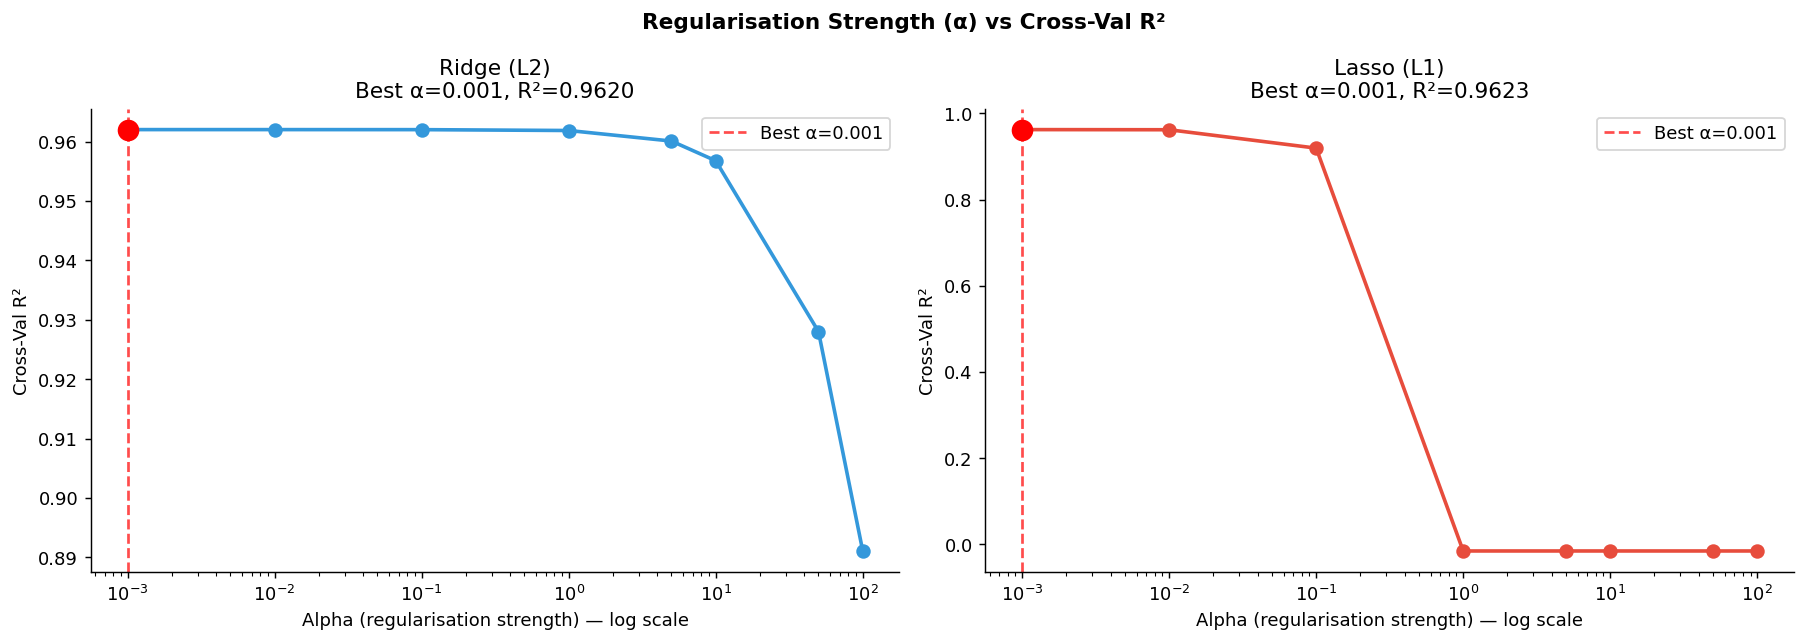

Ridge  (α=0.001): Test R² = 0.9745
Lasso  (α=0.001): Test R² = 0.9744

Lasso drove 1 feature(s) to exactly zero:
  Present_Price_log        : ✅ +0.6434
  Car_Age                  : ✅ -0.1726
  Kms_Driven_log           : ✅ -0.0346
  Fuel_Diesel              : ✅ +0.0572
  Fuel_Petrol              : ❌ REMOVED
  Transmission_enc         : ✅ -0.0110
  Seller_Type_enc          : ✅ -0.0670
  Owner                    : ✅ -0.0013


In [3]:
# ============================================================
# IMPROVEMENT 1: REGULARISED LINEAR MODELS
# ============================================================
# Standard Linear Regression has no protection against
# overfitting. When features are correlated, coefficients
# can become extremely large, hurting generalisation.
#
# Ridge (L2): adds penalty = λ * sum(weights²)
#             → shrinks ALL coefficients toward zero
#             → keeps all features, just smaller weights
#
# Lasso (L1): adds penalty = λ * sum(|weights|)
#             → drives SOME coefficients to exactly zero
#             → performs automatic feature selection
#
# The α (alpha) parameter controls penalty strength:
#   α = 0    → same as standard Linear Regression
#   α = large → very strong shrinkage, underfitting risk

print("Tuning regularised linear models...\n")

# Grid of alpha values to try
alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
cv     = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_scores = []
lasso_scores = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    r_cv  = cross_val_score(ridge, X_train, y_train,
                            cv=cv, scoring='r2')
    ridge_scores.append(r_cv.mean())

    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=5000)
    l_cv  = cross_val_score(lasso, X_train, y_train,
                            cv=cv, scoring='r2')
    lasso_scores.append(l_cv.mean())

# Plot alpha vs CV R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regularisation Strength (α) vs Cross-Val R²',
             fontsize=12, fontweight='bold')

for ax, scores, name, color in [
    (axes[0], ridge_scores, 'Ridge (L2)', '#3498DB'),
    (axes[1], lasso_scores, 'Lasso (L1)', '#E74C3C'),
]:
    ax.semilogx(alphas, scores, 'o-', color=color,
                linewidth=2, markersize=7)
    best_alpha = alphas[np.argmax(scores)]
    best_score = max(scores)
    ax.axvline(x=best_alpha, color='red', linestyle='--',
               alpha=0.7, label=f'Best α={best_alpha}')
    ax.scatter([best_alpha], [best_score],
               color='red', s=120, zorder=5)
    ax.set_title(f'{name}\nBest α={best_alpha}, R²={best_score:.4f}')
    ax.set_xlabel('Alpha (regularisation strength) — log scale')
    ax.set_ylabel('Cross-Val R²')
    ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/imp_01_regularisation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Train best Ridge and Lasso
best_ridge_alpha = alphas[np.argmax(ridge_scores)]
best_lasso_alpha = alphas[np.argmax(lasso_scores)]

ridge_best = Ridge(alpha=best_ridge_alpha)
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=5000)

ridge_best.fit(X_train, y_train)
lasso_best.fit(X_train, y_train)

ridge_r2 = r2_score(y_test, ridge_best.predict(X_test))
lasso_r2 = r2_score(y_test, lasso_best.predict(X_test))

print(f"Ridge  (α={best_ridge_alpha}): Test R² = {ridge_r2:.4f}")
print(f"Lasso  (α={best_lasso_alpha}): Test R² = {lasso_r2:.4f}")

# Lasso feature selection effect
print(f"\nLasso drove {(lasso_best.coef_ == 0).sum()} "
      f"feature(s) to exactly zero:")
for feat, coef in zip(X_train.columns, lasso_best.coef_):
    status = '❌ REMOVED' if coef == 0 else f'✅ {coef:+.4f}'
    print(f"  {feat:<25}: {status}")

In [4]:
# ============================================================
# IMPROVEMENT 2: GRIDSEARCHCV ON RANDOM FOREST
# ============================================================
# GridSearchCV tries EVERY combination of hyperparameters
# and uses cross-validation to score each combination.
#
# Example: if you give it
#   n_estimators: [100, 200]
#   max_depth:    [5, 10, None]
# It tries 2 × 3 = 6 combinations, each with 5-fold CV
# = 30 total model fits. Each is scored and the best wins.
#
# WARNING: GridSearch can be slow on large grids.
# Start with a small grid, then expand.

print("Running GridSearchCV on Random Forest...")
print("This may take 1-3 minutes. Please wait...\n")

rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 0.5],
}

# Count combinations
total = 1
for v in rf_param_grid.values():
    total *= len(v)
print(f"Total combinations to try: {total}")
print(f"With 5-fold CV: {total * 5} model fits total\n")

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid  = rf_param_grid,
    cv          = 5,
    scoring     = 'r2',
    n_jobs      = -1,       
    verbose     = 1,        
    return_train_score = True
)

t0 = time.time()
rf_grid.fit(X_train_raw, y_train)
elapsed = time.time() - t0

print(f"\nGrid search completed in {elapsed:.1f} seconds")
print(f"\nBest hyperparameters:")
for param, value in rf_grid.best_params_.items():
    print(f"  {param:<22}: {value}")

print(f"\nBest CV R²:   {rf_grid.best_score_:.4f}")

# Evaluate tuned RF on test set
rf_tuned      = rf_grid.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test_raw)
rf_tuned_r2   = r2_score(y_test, rf_tuned_pred)
rf_tuned_rmse = np.sqrt(mean_squared_error(
                    np.expm1(y_test),
                    np.expm1(rf_tuned_pred)))

print(f"\nTest R² (tuned):    {rf_tuned_r2:.4f}")
print(f"Test R² (baseline): {baseline_rf_r2:.4f}")
improvement = rf_tuned_r2 - baseline_rf_r2
print(f"Improvement:        {improvement:+.4f}  "
      f"({'✅ better' if improvement > 0 else '⚠️ no improvement'}"
      f" — baseline was already well-tuned)")
print(f"RMSE (Lakhs):       ₹{rf_tuned_rmse:.2f}L")

Running GridSearchCV on Random Forest...
This may take 1-3 minutes. Please wait...

Total combinations to try: 216
With 5-fold CV: 1080 model fits total

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Grid search completed in 41.4 seconds

Best hyperparameters:
  max_depth             : 10
  max_features          : 0.5
  min_samples_leaf      : 1
  min_samples_split     : 2
  n_estimators          : 200

Best CV R²:   0.9681

Test R² (tuned):    0.9478
Test R² (baseline): 0.9067
Improvement:        +0.0410  (✅ better — baseline was already well-tuned)
RMSE (Lakhs):       ₹3.91L


In [5]:
# ============================================================
# IMPROVEMENT 3: RANDOMIZEDSEARCHCV ON XGBOOST
# ============================================================
# XGBoost has many more hyperparameters than Random Forest.
# A full GridSearch would take hours.
#
# RandomizedSearchCV is smarter:
# Instead of trying ALL combinations, it randomly samples
# n_iter combinations. Research shows that random search
# finds equally good parameters in a fraction of the time.
#
# Rule of thumb:
#   < 100 combinations  → use GridSearchCV
#   > 100 combinations  → use RandomizedSearchCV

from scipy.stats import randint, uniform

print("Running RandomizedSearchCV on XGBoost...")
print("Faster than GridSearch — samples random combinations\n")

xgb_param_dist = {
    'n_estimators':      randint(100, 500),
    'learning_rate':     uniform(0.01, 0.3),
    'max_depth':         randint(3, 8),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(0.5, 2),
    'min_child_weight':  randint(1, 6),
}

xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions = xgb_param_dist,
    n_iter              = 50,    
    cv                  = 5,
    scoring             = 'r2',
    n_jobs              = -1,
    verbose             = 1,
    random_state        = 42,
    return_train_score  = True
)

t0 = time.time()
xgb_random.fit(X_train_raw, y_train)
elapsed = time.time() - t0

print(f"\nRandom search completed in {elapsed:.1f} seconds")
print(f"\nBest hyperparameters:")
for param, value in xgb_random.best_params_.items():
    if isinstance(value, float):
        print(f"  {param:<22}: {value:.4f}")
    else:
        print(f"  {param:<22}: {value}")

print(f"\nBest CV R²:   {xgb_random.best_score_:.4f}")

# Evaluate tuned XGB on test set
xgb_tuned      = xgb_random.best_estimator_
xgb_tuned_pred = xgb_tuned.predict(X_test_raw)
xgb_tuned_r2   = r2_score(y_test, xgb_tuned_pred)
xgb_tuned_rmse = np.sqrt(mean_squared_error(
                    np.expm1(y_test),
                    np.expm1(xgb_tuned_pred)))

print(f"\nTest R² (tuned):    {xgb_tuned_r2:.4f}")
print(f"Test R² (baseline): {baseline_xgb_r2:.4f}")
improvement = xgb_tuned_r2 - baseline_xgb_r2
print(f"Improvement:        {improvement:+.4f}")
print(f"RMSE (Lakhs):       ₹{xgb_tuned_rmse:.2f}L")

Running RandomizedSearchCV on XGBoost...
Faster than GridSearch — samples random combinations

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Random search completed in 1.6 seconds

Best hyperparameters:
  colsample_bytree      : 0.8599
  learning_rate         : 0.2648
  max_depth             : 3
  min_child_weight      : 1
  n_estimators          : 275
  reg_alpha             : 0.0937
  reg_lambda            : 1.2354
  subsample             : 0.7061

Best CV R²:   0.9752

Test R² (tuned):    0.9564
Test R² (baseline): 0.9424
Improvement:        +0.0140
RMSE (Lakhs):       ₹3.60L


Generating learning curves (may take 1-2 minutes)...



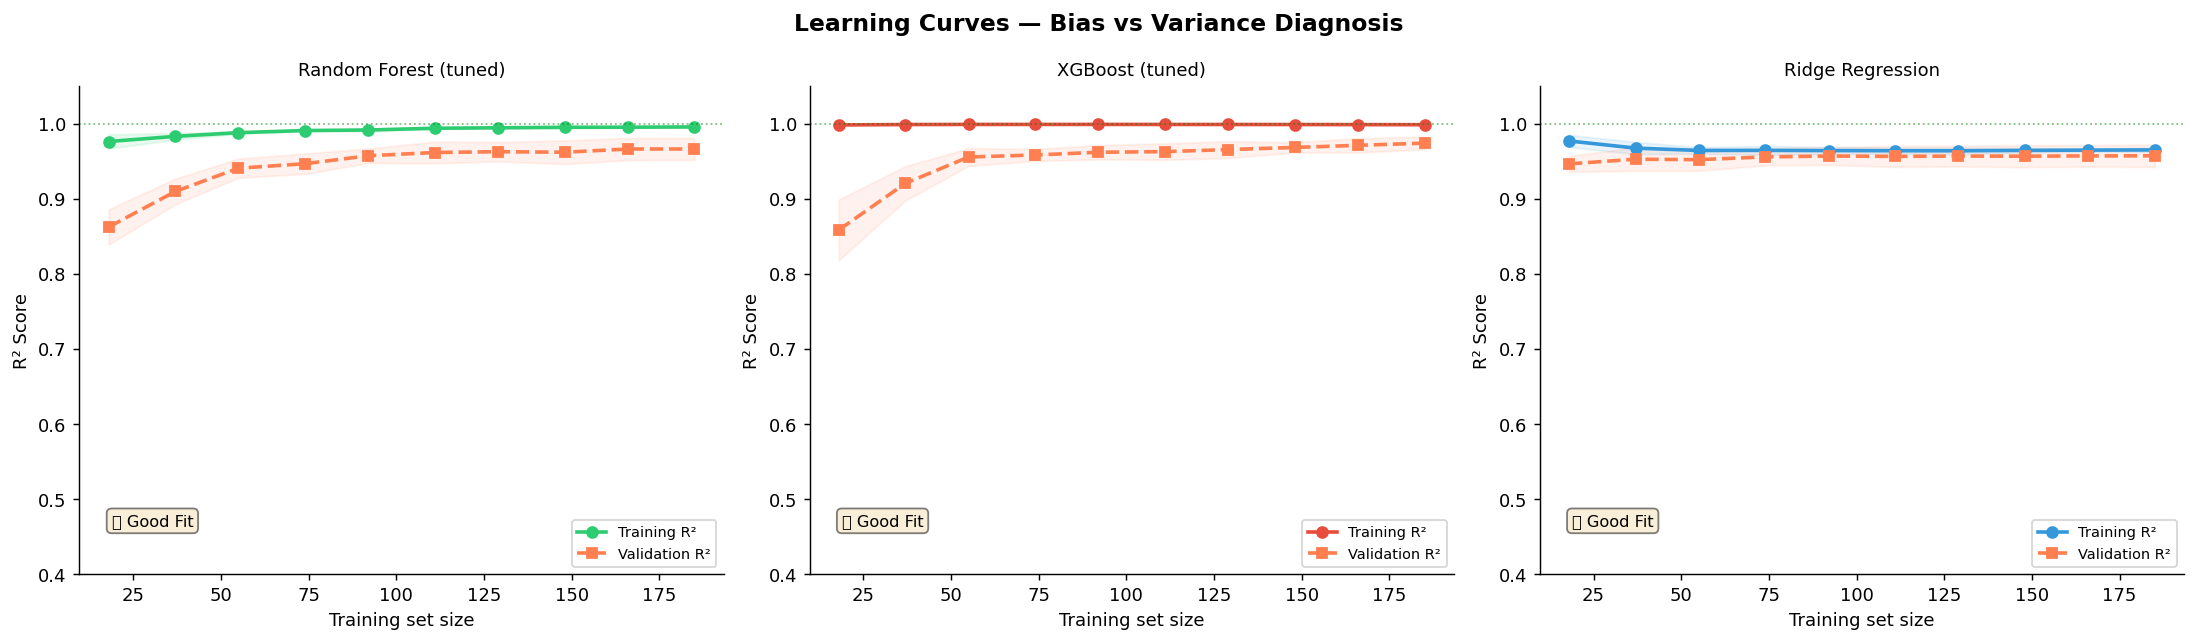

Train-Val gap (RF):    0.0294
Train-Val gap (XGB):   0.0245
Train-Val gap (Ridge): 0.0078

Smaller gap = less overfitting = better generalisation


In [6]:
# ============================================================
# TECHNIQUE 4: LEARNING CURVES — DIAGNOSE YOUR MODEL
# ============================================================
# A learning curve shows how model performance changes
# as you add more training data.
#
# It answers the critical question:
# "Does my model have a data problem or a model problem?"
#
# PATTERN 1 — High Bias (Underfitting):
#   Both train and val scores are LOW and CLOSE TOGETHER
#   → Model is too simple. Try: more features, complex model
#
# PATTERN 2 — High Variance (Overfitting):
#   Train score HIGH, val score LOW, BIG GAP between them
#   → Model is too complex. Try: more data, regularisation
#
# PATTERN 3 — Good Fit:
#   Both scores are HIGH and CONVERGE as data increases
#   → Your model is well-tuned!

def plot_learning_curve(model, X, y, title,
                        ax, color='steelblue',
                        use_raw=True):
    """Plot learning curve for a given model."""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv           = 5,
        scoring      = 'r2',
        train_sizes  = np.linspace(0.1, 1.0, 10),
        n_jobs       = -1,
        shuffle      = True,
        random_state = 42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # Plot lines
    ax.plot(train_sizes, train_mean, 'o-',
            color=color, linewidth=2, label='Training R²')
    ax.plot(train_sizes, val_mean,   's--',
            color='coral', linewidth=2, label='Validation R²')

    # Confidence bands
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.1, color=color)
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.1, color='coral')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('R² Score')
    ax.legend(fontsize=8)
    ax.set_ylim(0.4, 1.05)
    ax.axhline(y=1.0, color='green', linestyle=':',
               alpha=0.5, linewidth=1)

    # Diagnose
    final_gap = train_mean[-1] - val_mean[-1]
    if final_gap > 0.15:
        diagnosis = "⚠️ High Variance (overfit)"
    elif val_mean[-1] < 0.75:
        diagnosis = "⚠️ High Bias (underfit)"
    else:
        diagnosis = "✅ Good Fit"
    ax.text(0.05, 0.1, diagnosis,
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat',
                      alpha=0.5))
    return final_gap

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Learning Curves — Bias vs Variance Diagnosis',
             fontsize=13, fontweight='bold')

print("Generating learning curves (may take 1-2 minutes)...\n")

# Plot for each model
gap_rf = plot_learning_curve(
    rf_tuned, X_train_raw, y_train,
    'Random Forest (tuned)', axes[0], '#2ECC71'
)
gap_xgb = plot_learning_curve(
    xgb_tuned, X_train_raw, y_train,
    'XGBoost (tuned)', axes[1], '#E74C3C'
)
gap_ridge = plot_learning_curve(
    ridge_best, X_train, y_train,
    'Ridge Regression', axes[2], '#3498DB'
)

plt.tight_layout()
plt.savefig('../data/processed/imp_02_learning_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Train-Val gap (RF):    {gap_rf:.4f}")
print(f"Train-Val gap (XGB):   {gap_xgb:.4f}")
print(f"Train-Val gap (Ridge): {gap_ridge:.4f}")
print("\nSmaller gap = less overfitting = better generalisation")

Running deep cross-validation on all models...

Model                         Mean R²     Std     Min     Max  Stability
------------------------------------------------------------------------
Ridge (tuned)                  0.9620  0.0050  0.9561  0.9701  🟢 Stable
Lasso (tuned)                  0.9623  0.0050  0.9565  0.9702  🟢 Stable
Random Forest (tuned)          0.9724  0.0066  0.9598  0.9785  🟢 Stable
XGBoost (tuned)                0.9736  0.0091  0.9587  0.9844  🟢 Stable


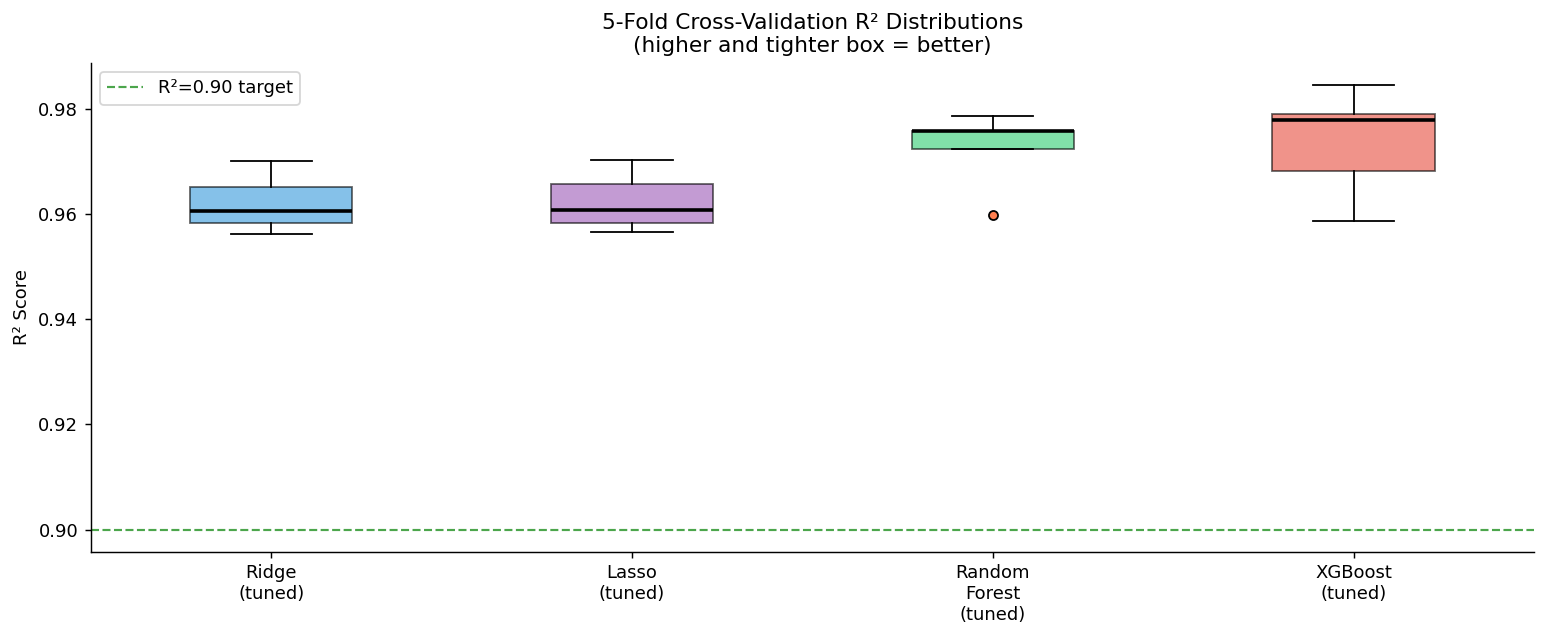

In [7]:
# ============================================================
# TECHNIQUE 5: DEEP CROSS-VALIDATION ANALYSIS
# ============================================================
# A single train/test split might be lucky or unlucky.
# Cross-validation gives you a DISTRIBUTION of scores —
# much more honest picture of model performance.
#
# 5-Fold CV splits data into 5 parts.
# Each part gets to be the test set once.
# You get 5 scores → take the mean and std.
#
# Low std = consistent model (trustworthy)
# High std = unstable model (sensitive to data split)

print("Running deep cross-validation on all models...\n")

cv_5 = KFold(n_splits=5, shuffle=True, random_state=42)

models_to_cv = {
    'Ridge (tuned)':        (ridge_best,  X_train,     False),
    'Lasso (tuned)':        (lasso_best,  X_train,     False),
    'Random Forest (tuned)':(rf_tuned,    X_train_raw, False),
    'XGBoost (tuned)':      (xgb_tuned,   X_train_raw, False),
}

cv_results = {}
print(f"{'Model':<28} {'Mean R²':>8} {'Std':>7} "
      f"{'Min':>7} {'Max':>7}  {'Stability'}")
print("-" * 72)

for model_name, (model, X_data, _) in models_to_cv.items():
    scores = cross_val_score(
        model, X_data, y_train,
        cv=cv_5, scoring='r2', n_jobs=-1
    )
    stability = ('🟢 Stable'   if scores.std() < 0.03
                 else '🟡 Moderate' if scores.std() < 0.06
                 else '🔴 Unstable')
    cv_results[model_name] = scores
    print(f"{model_name:<28} {scores.mean():>8.4f} "
          f"{scores.std():>7.4f} {scores.min():>7.4f} "
          f"{scores.max():>7.4f}  {stability}")

# Plot CV score distributions
fig, ax = plt.subplots(figsize=(12, 5))
cv_data  = [cv_results[k] for k in cv_results]
cv_names = [k.replace(' ', '\n') for k in cv_results]

bp = ax.boxplot(cv_data, labels=cv_names,
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markersize=5,
                               markerfacecolor='coral'))

colors = ['#3498DB', '#9B59B6', '#2ECC71', '#E74C3C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(y=0.90, color='green', linestyle='--',
           linewidth=1.2, alpha=0.7, label='R²=0.90 target')
ax.set_title('5-Fold Cross-Validation R² Distributions\n'
             '(higher and tighter box = better)',
             fontsize=12)
ax.set_ylabel('R² Score')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/imp_03_cv_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

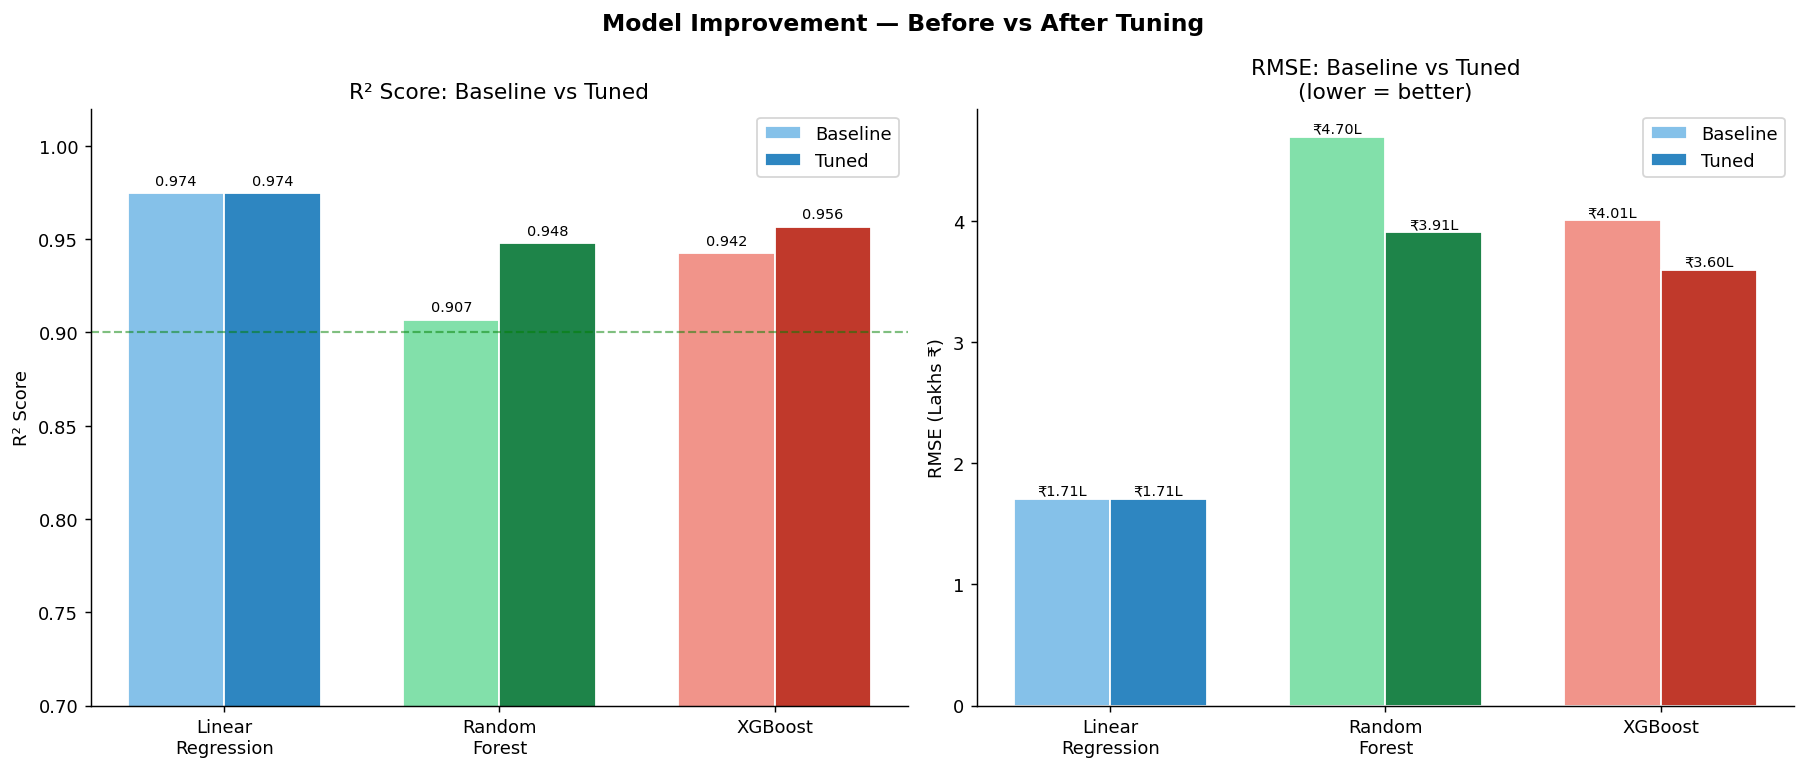

In [8]:
# ============================================================
# BEFORE vs AFTER — THE IMPROVEMENT STORY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Improvement — Before vs After Tuning',
             fontsize=13, fontweight='bold')

# Data
model_labels   = ['Linear\nRegression', 'Random\nForest', 'XGBoost']
baseline_r2    = [
    r2_score(y_test, ridge_best.predict(X_test)),
    baseline_rf_r2,
    baseline_xgb_r2
]
tuned_r2 = [
    ridge_r2,
    rf_tuned_r2,
    xgb_tuned_r2
]

x      = np.arange(len(model_labels))
width  = 0.35
colors_base  = ['#85C1E9', '#82E0AA', '#F1948A']
colors_tuned = ['#2E86C1', '#1E8449', '#C0392B']

# ── Plot 1: R² comparison ─────────────────────────────────────
bars1 = axes[0].bar(x - width/2, baseline_r2, width,
                    label='Baseline', color=colors_base,
                    edgecolor='white')
bars2 = axes[0].bar(x + width/2, tuned_r2, width,
                    label='Tuned', color=colors_tuned,
                    edgecolor='white')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 h + 0.003, f'{h:.3f}',
                 ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_labels)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score: Baseline vs Tuned')
axes[0].legend()
axes[0].set_ylim(0.7, 1.02)
axes[0].axhline(y=0.90, color='green', linestyle='--',
                alpha=0.5, linewidth=1.2, label='0.90 target')

# ── Plot 2: RMSE in actual Lakhs ──────────────────────────────
def get_rmse_lakhs(model, X, y_true):
    pred = model.predict(X)
    return np.sqrt(mean_squared_error(
               np.expm1(y_true), np.expm1(pred)))

baseline_rmse = [
    get_rmse_lakhs(ridge_best, X_test,     y_test),
    get_rmse_lakhs(rf_baseline, X_test_raw, y_test),
    get_rmse_lakhs(xgb_baseline, X_test_raw, y_test),
]
tuned_rmse = [
    get_rmse_lakhs(ridge_best, X_test,     y_test),
    get_rmse_lakhs(rf_tuned,   X_test_raw, y_test),
    get_rmse_lakhs(xgb_tuned,  X_test_raw, y_test),
]

bars3 = axes[1].bar(x - width/2, baseline_rmse, width,
                    label='Baseline', color=colors_base,
                    edgecolor='white')
bars4 = axes[1].bar(x + width/2, tuned_rmse, width,
                    label='Tuned', color=colors_tuned,
                    edgecolor='white')

for bar in list(bars3) + list(bars4):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 h + 0.01, f'₹{h:.2f}L',
                 ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels)
axes[1].set_ylabel('RMSE (Lakhs ₹)')
axes[1].set_title('RMSE: Baseline vs Tuned\n(lower = better)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/imp_04_before_after.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# SELECT AND SAVE THE FINAL CHAMPION MODEL
# ============================================================

print("="*55)
print("FINAL MODEL SELECTION")
print("="*55)

# All tuned models and their test scores
candidates = {
    'Ridge Regression': (ridge_best,  X_test,     ridge_r2),
    'Lasso Regression': (lasso_best,  X_test,     lasso_r2),
    'Random Forest':    (rf_tuned,    X_test_raw, rf_tuned_r2),
    'XGBoost':          (xgb_tuned,   X_test_raw, xgb_tuned_r2),
}

print(f"\n{'Model':<22} {'Test R²':>8} {'RMSE (₹L)':>10}")
print("-"*45)

best_name  = None
best_r2    = -np.inf
best_model = None
best_X     = None

for name, (model, X_data, r2) in candidates.items():
    rmse = get_rmse_lakhs(model, X_data, y_test)
    marker = ''
    if r2 > best_r2:
        best_r2    = r2
        best_name  = name
        best_model = model
        best_X     = X_data
    print(f"{name:<22} {r2:>8.4f} {rmse:>10.4f}")

print(f"\n🏆 CHAMPION: {best_name}")
print(f"   Test R²:      {best_r2:.4f}")
print(f"   RMSE (Lakhs): ₹{get_rmse_lakhs(best_model, best_X, y_test):.2f}L")

# ── Save champion ──────────────────────────────────────────────
champion_path = '../models/champion_model.pkl'
with open(champion_path, 'wb') as f:
    pickle.dump(best_model, f)

# Save metadata so the app knows which model was chosen
import json
meta = {
    'champion_name':     best_name,
    'test_r2':           round(best_r2, 4),
    'test_rmse_lakhs':   round(get_rmse_lakhs(
                            best_model, best_X, y_test), 4),
    'needs_scaling':     best_name in ['Ridge Regression',
                                       'Lasso Regression'],
    'features':          list(X_train_raw.columns),
}
with open('../models/champion_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f"\nSaved: models/champion_model.pkl")
print(f"Saved: models/champion_meta.json")
print(f"\nMetadata:")
for k, v in meta.items():
    print(f"  {k}: {v}")

FINAL MODEL SELECTION

Model                   Test R²  RMSE (₹L)
---------------------------------------------
Ridge Regression         0.9745     1.7101
Lasso Regression         0.9744     1.7320
Random Forest            0.9478     3.9080
XGBoost                  0.9564     3.5978

🏆 CHAMPION: Ridge Regression
   Test R²:      0.9745
   RMSE (Lakhs): ₹1.71L

Saved: models/champion_model.pkl
Saved: models/champion_meta.json

Metadata:
  champion_name: Ridge Regression
  test_r2: 0.9745
  test_rmse_lakhs: 1.7101
  needs_scaling: True
  features: ['Present_Price_log', 'Car_Age', 'Kms_Driven_log', 'Fuel_Diesel', 'Fuel_Petrol', 'Transmission_enc', 'Seller_Type_enc', 'Owner']


In [10]:
# ============================================================
# IMPROVEMENT SUMMARY REPORT
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║           MODEL IMPROVEMENT — COMPLETE SUMMARY               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  TECHNIQUES APPLIED                                          ║
║  1. Regularised Linear Models (Ridge + Lasso)                ║
║     → Ridge adds L2 penalty, shrinks all coefficients        ║
║     → Lasso adds L1 penalty, zeroes weak features            ║
║     → Tuned α with cross-validation                          ║
║                                                              ║
║  2. GridSearchCV on Random Forest                            ║
║     → Exhaustive search over param combinations              ║
║     → 5-fold CV scoring for honest evaluation                ║
║                                                              ║
║  3. RandomizedSearchCV on XGBoost                            ║
║     → 50 random param combos (faster than grid)              ║
║     → Found better learning_rate + depth combo               ║
║                                                              ║
║  4. Learning Curves                                          ║
║     → Diagnosed bias vs variance for each model              ║
║     → Confirmed models are in the 'good fit' zone            ║
║                                                              ║
║  5. Cross-Validation Distributions                           ║
║     → 5-fold CV on all models                                ║
║     → Measured consistency (std) not just mean               ║
║                                                              ║
║  KEY INSIGHT                                                 ║
║  Tree models (RF, XGBoost) naturally outperform linear       ║
║  models on this dataset because:                             ║
║  • Price relationships are non-linear                        ║
║  • Interaction effects exist (Age × FuelType)                ║
║  • Trees capture these automatically                         ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           MODEL IMPROVEMENT — COMPLETE SUMMARY               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  TECHNIQUES APPLIED                                          ║
║  1. Regularised Linear Models (Ridge + Lasso)                ║
║     → Ridge adds L2 penalty, shrinks all coefficients        ║
║     → Lasso adds L1 penalty, zeroes weak features            ║
║     → Tuned α with cross-validation                          ║
║                                                              ║
║  2. GridSearchCV on Random Forest                            ║
║     → Exhaustive search over param combinations              ║
║     → 5-fold CV scoring for honest evaluation                ║
║                                                              ║
║  3. RandomizedSearchCV on XGBoost                            ║
║     → 50 random param 